<a href="https://colab.research.google.com/github/andrebrandaopro/Lista2/blob/Portf%C3%B3lio/q5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classificação de câncer de mama com múltiplas pastas do dataset IDC

Este notebook utiliza imagens de várias pastas do dataset Breast Histopathology Images (IDC) para classificação em tecido canceroso e não canceroso usando uma ResNet18 pré-treinada.

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

## Carregamento e preparação dos dados

O diretório `IDC_regular_ps50_idx5_subset` deve conter subpastas `0` e `1` com imagens de várias pastas do dataset original.

In [3]:
import kagglehub
import os
import shutil

path = kagglehub.dataset_download("paultimothymooney/breast-histopathology-images")


folders = ["10253", "10254", "10255", "10256", "10257"]

dst_root = "./IDC_regular_ps50_idx5_subset"
os.makedirs(dst_root, exist_ok=True)

for folder in folders:
    for cls in ['0', '1']:
        src_dir = os.path.join(path, "IDC_regular_ps50_idx5", folder, cls)
        dst_dir = os.path.join(dst_root, cls)
        os.makedirs(dst_dir, exist_ok=True)
        if os.path.exists(src_dir):
            files = [f for f in os.listdir(src_dir) if os.path.isfile(os.path.join(src_dir, f))]
            n = min(80, len(files))
            for f in files[:n]:
                shutil.copy(os.path.join(src_dir, f), os.path.join(dst_dir, f"{folder}_{f}"))

print("Imagens copiadas por classe:")
print("Classe 0:", len(os.listdir(os.path.join(dst_root, '0'))))
print("Classe 1:", len(os.listdir(os.path.join(dst_root, '1'))))

Imagens copiadas por classe:
Classe 0: 400
Classe 1: 386


In [4]:
data_dir = './IDC_regular_ps50_idx5_subset'

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

dataset = datasets.ImageFolder(root=data_dir, transform=transform)
n_total = len(dataset)
n_train = int(0.8 * n_total)
n_test = n_total - n_train
train_ds, test_ds = random_split(dataset, [n_train, n_test], generator=torch.Generator().manual_seed(42))
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)
class_names = dataset.classes

## Visualização de exemplos do dataset

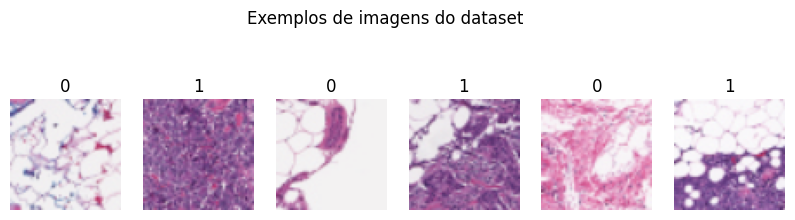

In [5]:
def imshow(inp, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title:
        plt.title(title)
    plt.axis('off')

inputs, classes_ = next(iter(train_loader))
plt.figure(figsize=(10,3))
for i in range(6):
    plt.subplot(1,6,i+1)
    imshow(inputs[i], class_names[classes_[i]])
plt.suptitle('Exemplos de imagens do dataset')
plt.show()

## Definição do modelo e setup de treinamento

Utiliza-se uma ResNet18 pré-treinada, adaptando a última camada para duas classes.

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
for param in model.parameters():
    param.requires_grad = False
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 83.7MB/s]


## Treinamento da rede

In [11]:
n_epochs = 10
for epoch in range(n_epochs):
    model.train()
    loss_sum = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * inputs.size(0)
    epoch_loss = loss_sum / len(train_loader.dataset)
    print(f'Epoch {epoch+1}/{n_epochs} - loss: {epoch_loss:.4f}')

Epoch 1/10 - loss: 0.2341
Epoch 2/10 - loss: 0.1802
Epoch 3/10 - loss: 0.2563
Epoch 4/10 - loss: 0.2297
Epoch 5/10 - loss: 0.2153
Epoch 6/10 - loss: 0.2122
Epoch 7/10 - loss: 0.2252
Epoch 8/10 - loss: 0.1998
Epoch 9/10 - loss: 0.1932
Epoch 10/10 - loss: 0.2458


## Avaliação dos resultados

São exibidas matriz de confusão, métricas e curva ROC/AUC.

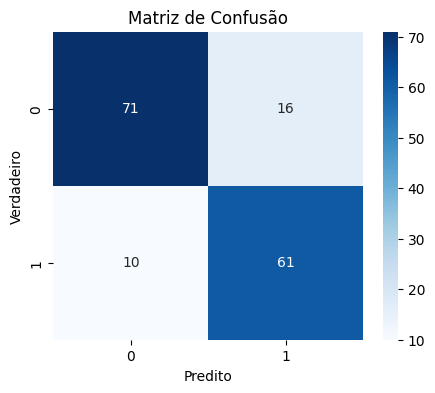

              precision    recall  f1-score   support

           0       0.88      0.82      0.85        87
           1       0.79      0.86      0.82        71

    accuracy                           0.84       158
   macro avg       0.83      0.84      0.83       158
weighted avg       0.84      0.84      0.84       158



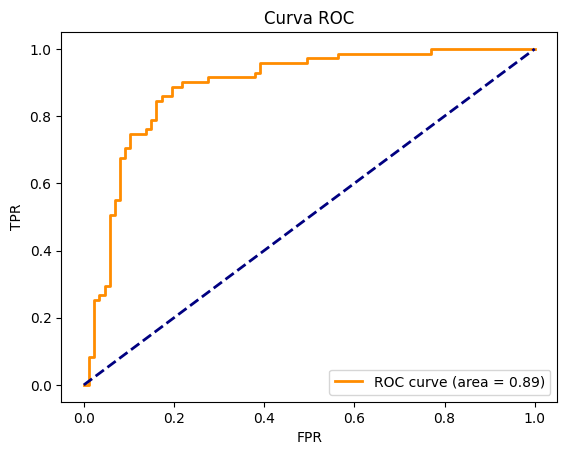

In [12]:
model.eval()
y_true, y_pred, y_score = [], [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(probs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_score.extend(probs[:,1].cpu().numpy())

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predito')
plt.ylabel('Verdadeiro')
plt.title('Matriz de Confusão')
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

fpr, tpr, thresholds = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.show()